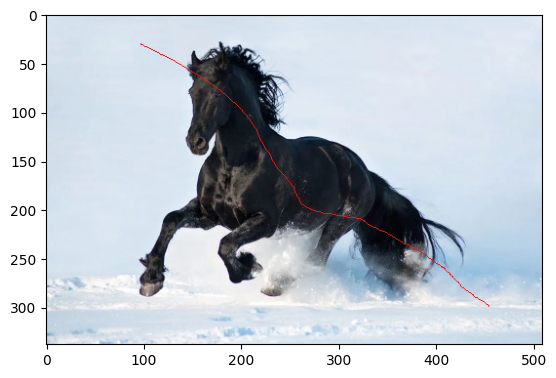

In [15]:
import matplotlib.pyplot as plt
import numpy as np

photo_couleur = plt.imread("cheval-abime2.png").astype(float)
photo_nb = plt.imread("cheval-abime2-nb.png").astype(float)
trace = plt.imread("cheval-abime2-mask.png").astype(float)

plt.imshow(photo_couleur)

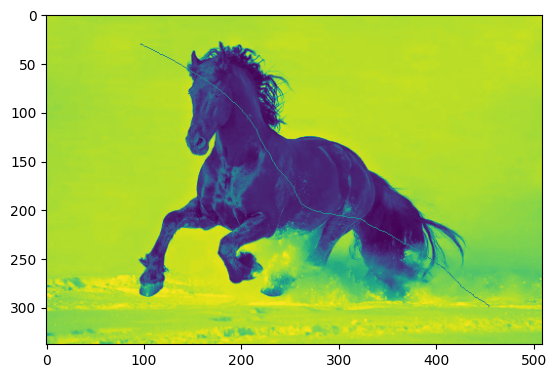

In [16]:
plt.imshow(photo_nb)

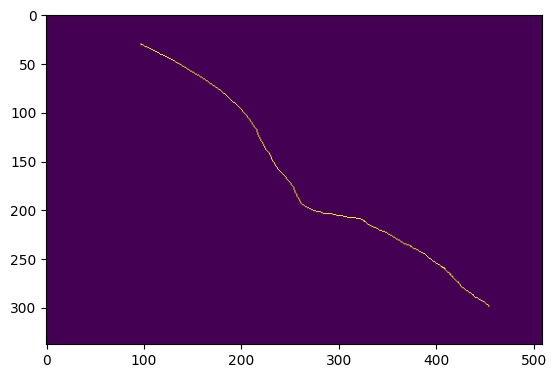

In [17]:
plt.imshow(trace)

In [18]:
def iterative_svd_recovery(A, mask, k, eps):
    A = A.copy().astype(float)
    
    while True:
        # Étape 1 : SVD recalculée sur A courant
        U, s, Vt = np.linalg.svd(A, full_matrices=False)
        Ak = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :] 
        """
            U : matrice des vecteurs singuliers à gauche
            s : vecteurs singuliers (valeurs propres)
            Vt : matrice des vecteurs singuliers à droite transposée
            Ak : approximation de rang k de A
        """
        
        # Étape 2
        A_tilde = A.copy()
        A_tilde[mask] = Ak[mask]
        
        # Étape 3
        if np.linalg.norm(A - A_tilde, 'fro') < eps:
            break
        
        A = A_tilde
    
    return A


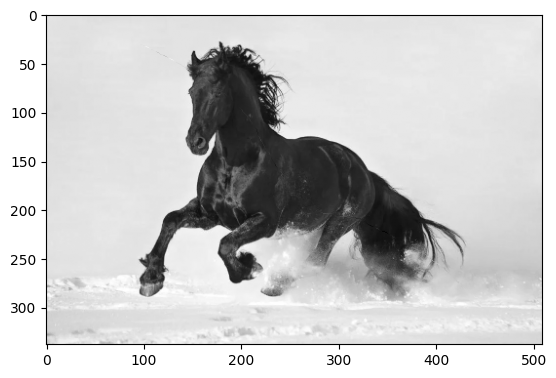

In [31]:
mask = plt.imread("cheval-abime2-mask.png")
if mask.ndim == 3:
    mask = mask[:, :, 0]
mask = (mask > 0.5).astype(bool)

restored_nb = iterative_svd_recovery(photo_couleur, mask, k=15, eps=1e-3)
plt.imshow(restored_nb, cmap="gray")